In [8]:
# 1. IMPORTATIONS POUR LE M3 (Sélection + Random Forest)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler


/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
# Toujours le log pour Kaggle !
y_train = np.log1p(train_df['SalePrice'])

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [10]:
# 3. CRÉATION DU PREPROCESSOR (RobustScaler + OneHot)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [11]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M3)

# Étape A : Le Filtre Lasso
# SelectFromModel va utiliser un LassoCV en interne. Il gardera uniquement les variables dont le coefficient n'a pas été réduit à 0.
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : Le Modèle Random Forest (Artillerie lourde)
# On initialise une Forêt Aléatoire de base
rf_model = RandomForestRegressor(random_state=42)

# Étape C : Assemblage de la Super Pipeline
pipeline_m3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_model)
])

# Étape D : Optimisation avec Optuna (plus intelligent que RandomizedSearchCV)
def objective(trial):
    """
    Fonction objective pour Optuna : teste différentes combos d'hyperparamètres
    et retourne le RMSE moyen en validation croisée
    """
    # Optuna suggère les hyperparamètres
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    # Créer une nouvelle pipeline avec ces hyperparamètres
    rf_model_trial = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    pipeline_trial = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('rf', rf_model_trial)
    ])

    # Évaluation avec cross-validation (scoring: neg_rmse)
    cv_scores = cross_val_score(
        pipeline_trial,
        X_train,
        y_train,
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    # Optuna minimise, donc on retourne la moyenne (négative = rmse en négatif)
    return cv_scores.mean()

# Étape E : Lancement de l'étude Optuna
print("Lancement de l'optimisation Optuna (recherche bayésienne intelligente)...")
print("Cela va tester ~50 combinaisons et apprendre des résultats précédents...\n")

# Sampler Bayésien (TPE = Tree-structured Parzen Estimator)
sampler = TPESampler(seed=42)

study = optuna.create_study(
    direction='maximize',  # On maximise car cross_val_score retourne une valeur négative (-rmse)
    sampler=sampler
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)

# Réentraîner le meilleur modèle avec les meilleurs paramètres
best_params = study.best_params
rf_best = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42,
    n_jobs=-1
)

best_m3_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_best)
])

# Fit sur tout le train set
best_m3_pipeline.fit(X_train, y_train)

# Évaluation sur le Train Set
y_pred_train = best_m3_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

[I 2026-05-21 16:29:06,931] A new study created in memory with name: no-name-f71450bd-55cc-4cec-9ba7-c4eb60f87be6


Lancement de l'optimisation Optuna (recherche bayésienne intelligente)...
Cela va tester ~50 combinaisons et apprendre des résultats précédents...



Best trial: 0. Best value: -0.148167:   2%|▏         | 1/50 [00:01<01:10,  1.45s/it]

[I 2026-05-21 16:29:08,378] Trial 0 finished with value: -0.14816731316276008 and parameters: {'n_estimators': 200, 'max_depth': 48, 'min_samples_split': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.14816731316276008.


Best trial: 0. Best value: -0.148167:   4%|▍         | 2/50 [00:02<00:57,  1.20s/it]

...

[I 2026-05-21 16:29:32,735] Trial 47 finished with value: -0.14362274085895727 and parameters: {'n_estimators': 100, 'max_depth': 38, 'min_samples_split': 2, 'max_features': 'sqrt'}. Best is trial 45 with value: -0.14190461137369886.


Best trial: 45. Best value: -0.141905:  98%|█████████▊| 49/50 [00:26<00:00,  2.83it/s]

[I 2026-05-21 16:29:33,172] Trial 48 finished with value: -0.143411491974077 and parameters: {'n_estimators': 200, 'max_depth': 35, 'min_samples_split': 5, 'max_features': 'sqrt'}. Best is trial 45 with value: -0.14190461137369886.


Best trial: 45. Best value: -0.141905: 100%|██████████| 50/50 [00:26<00:00,  1.88it/s]


[I 2026-05-21 16:29:33,488] Trial 49 finished with value: -0.14330101546971638 and parameters: {'n_estimators': 100, 'max_depth': 41, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 45 with value: -0.14190461137369886.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.1419
Meilleurs hyperparamètres trouvés :
{'n_estimators': 100, 'max_depth': 42, 'min_samples_split': 3, 'max_features': 'sqrt'}
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.0587


In [12]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m3 = best_m3_pipeline.predict(X_test)
preds_dollars_m3 = np.expm1(preds_log_m3) # Retour au prix en dollars

submission_m3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m3
})

fichier_soumission = 'M3_RandomForest_Submission.csv'
submission_m3.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M3_RandomForest_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


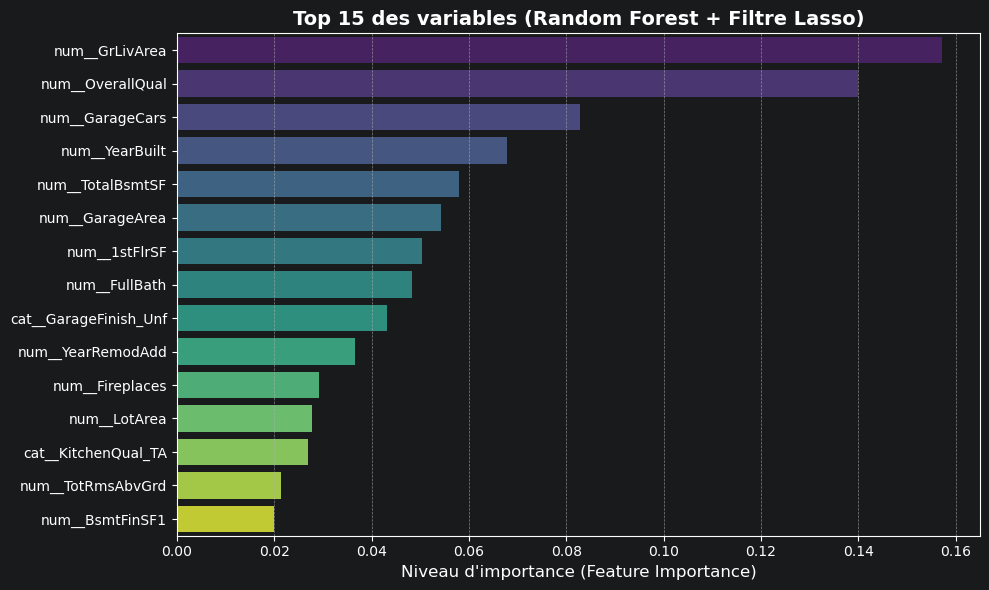

In [13]:
# 6. VISUALISATION : COMMENT LA FORÊT PREND SES DÉCISIONS ?

# Pour un Random Forest, l'importance des variables n'est pas "positive ou négative"
# comme un Lasso. C'est un pourcentage d'importance globale (de 0 à 1).

# 1. Récupérer toutes les variables créées par le preprocessor
toutes_variables = best_m3_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Récupérer le filtre (quelles variables le Lasso a laissé passer ?)
masque_lasso = best_m3_pipeline.named_steps['selector'].get_support()
variables_filtrees = toutes_variables[masque_lasso]

# 3. Récupérer l'importance donnée par le Random Forest
rf_importances = best_m3_pipeline.named_steps['rf'].feature_importances_

# 4. Créer le DataFrame et prendre le Top 15
rf_coef_df = pd.DataFrame({
    'Variable': variables_filtrees,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False).head(15)

# 5. Graphique avec Seaborn (version propre sans warning)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_coef_df,
    x='Importance',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title("Top 15 des variables (Random Forest + Filtre Lasso)", fontweight='bold', fontsize=14)
plt.xlabel("Niveau d'importance (Feature Importance)", fontsize=12)
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()